Пример решения задания FashionMNIST на pytorch



Для начала загрузим наши данные и сделаем простенькое EDA

In [1]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms


device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # выберем нашу видеокарту
print(f"Running on {device}.")


train_dataset = datasets.FashionMNIST(
    root='../data/raw',
    train=True,
    download=True,
    transform=transforms.ToTensor()
) # тренировочный датасет

test_dataset = datasets.FashionMNIST(
    root='../data/raw',
    train=False,
    download=True,
    transform=transforms.ToTensor()
) # тестовый датасет


classes = train_dataset.classes
print(f'train_dataset shape: {len(train_dataset)}, image shape: {train_dataset[0][0].shape}')

Running on cuda.
train_dataset shape: 60000, image shape: torch.Size([1, 28, 28])


In [2]:
print(torch.version.cuda)

12.8


посмотрим пару картиночек

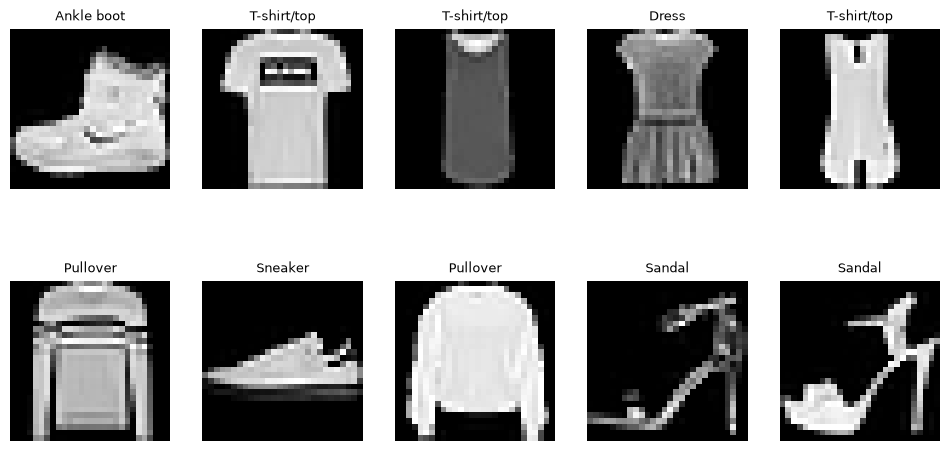

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(classes[label], fontsize=9)
    ax.axis('off') # видим что у нас 10 классов и картинки чбшные
    
plt.tight_layout
plt.show()

In [4]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


Сделаем класс ModelFactory что бы не писать код для каждой модели

In [5]:
import torch.nn as nn 
from torchvision import models


class ModelFactory: 
    @staticmethod
    def get_model(name: str, num_classes: int = 10, in_channels: int = 1, pretrained: bool = False):
        weights = 'DEFAULT' if pretrained else None
        name = name.lower()
        
        if name == 'resnet18':
            model = models.resnet18(weights=weights)
            if in_channels != 3:
                model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
            return model 
        
        elif name == 'alexnet':
            model = models.alexnet(weights=weights)
            if in_channels != 3:
                model.features[0] = nn.Conv2d(in_channels, 64, kernel_size=4, stride=1, padding=2)
            model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
            return model
        
        elif name == 'vgg11':
            model = models.vgg11(weights=weights)
            if in_channels != 3: 
                model.features[0] = nn.Conv2d(in_channels, 64, kernel_size = 3, padding=1)
            model.features[20] = nn.Identity()
            model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
            return model
        else: 
            raise ValueError(f"model {name} not founded")

сделаем тестовую модель

In [6]:
resnet_model = ModelFactory.get_model('resnet18', num_classes=10, in_channels=1, pretrained=False).to(device)

dummy_input = torch.randn(64, 1, 28, 28).to(device)
output = resnet_model(dummy_input)
print(f'output log size: {output.shape}')

output log size: torch.Size([64, 10])


теперь сделаем класс Trainer, он будет использоваться для быстрого обучения, что бы не прописывать алгоритм каждый раз

In [7]:
class Trainer:
    def __init__(self, model, criterion, optimizer, device):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        
    def train_epoch(self, dataloader):
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0
        
        for images, labels in dataloader:
            images, labels = images.to(self.device), labels.to(self.device)
            
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        return total_loss / total, correct / total
    
    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in dataloader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                
        return total_loss / total, correct / total
    
    def fit(self, train_loader, test_loader, epochs=5):
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(test_loader)
            print(f'Эпоха [{epoch}/ {epochs}]')
            print(f'Train loss: {train_loss:.4f}, train acc: {train_acc:.4f}')
            print(f'test loss: {val_loss:.4f}, test acc {val_acc:.4f}')
        
            
            
            

обучим нашу модель реснет


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-3)
trainer = Trainer(model = resnet_model,
                  criterion=criterion,
                  optimizer=optimizer,
                  device=device)

trainer.fit(train_loader, test_loader, epochs = 5) # запускает модель в режим обучения

Эпоха [1/ 5]
Train loss: 0.3559, train acc: 0.8699
test loss: 0.2719, test acc 0.8985
Эпоха [2/ 5]
Train loss: 0.2377, train acc: 0.9127
test loss: 0.2503, test acc 0.9103
Эпоха [3/ 5]
Train loss: 0.2021, train acc: 0.9271
test loss: 0.2332, test acc 0.9170
Эпоха [4/ 5]
Train loss: 0.1738, train acc: 0.9369
test loss: 0.2287, test acc 0.9185
Эпоха [5/ 5]
Train loss: 0.1485, train acc: 0.9456
test loss: 0.2313, test acc 0.9189


In [9]:
import pandas as pd

results = []
models_list = ['alexnet', 'vgg11']

for model_name in models_list:
    model = ModelFactory.get_model(model_name, num_classes=10, in_channels=1).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    trainer = Trainer(model=model, criterion=criterion, optimizer=optimizer, device=device)
    trainer.fit(train_loader, test_loader, epochs=5)
    test_loss, test_acc = trainer.evaluate(test_loader)
    results.append({
        'model': model_name,
        'test acc': round(test_acc * 100, 2)
    })
df_results = pd.DataFrame(results)
print(df_results)    
    

Эпоха [1/ 5]
Train loss: 0.6492, train acc: 0.7517
test loss: 0.4123, test acc 0.8511
Эпоха [2/ 5]
Train loss: 0.3750, train acc: 0.8623
test loss: 0.3471, test acc 0.8738
Эпоха [3/ 5]
Train loss: 0.3304, train acc: 0.8816
test loss: 0.3163, test acc 0.8868
Эпоха [4/ 5]
Train loss: 0.3039, train acc: 0.8898
test loss: 0.3262, test acc 0.8834
Эпоха [5/ 5]
Train loss: 0.2792, train acc: 0.9001
test loss: 0.2995, test acc 0.8929
Эпоха [1/ 5]
Train loss: 0.6898, train acc: 0.7377
test loss: 0.4516, test acc 0.8397
Эпоха [2/ 5]
Train loss: 0.3894, train acc: 0.8663
test loss: 0.3565, test acc 0.8731
Эпоха [3/ 5]
Train loss: 0.3291, train acc: 0.8890
test loss: 0.3564, test acc 0.8817
Эпоха [4/ 5]
Train loss: 0.3196, train acc: 0.8921
test loss: 0.3249, test acc 0.8895
Эпоха [5/ 5]
Train loss: 0.2967, train acc: 0.9008
test loss: 0.2952, test acc 0.8948
     model  test acc
0  alexnet     89.29
1    vgg11     89.48


In [10]:
from pathlib import Path

save_dir = Path("models_checkpoints")
save_dir.mkdir(parents=True, exist_ok=True)
torch.save(resnet_model.state_dict(), 'models_checkpoints/resnet18_fashion.pth')


сделаем матрицу ошибок для модели resnet, так как она показала себя лучше всего по метрике

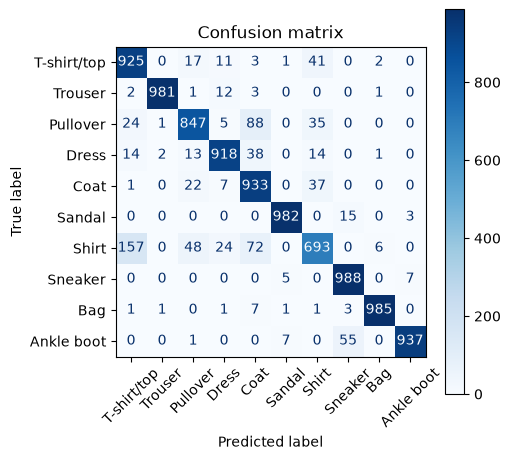

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []

resnet_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = resnet_model(images)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        
classes = test_loader.dataset.classes
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap="Blues", values_format='d', xticks_rotation=45)
plt.title('Confusion matrix')
plt.show()

видим что она справляется очень хорошо, только тупит на рубашках, тк путает их видимо с футболками и coat

In [12]:
def predict_image(model, image, label=None, device='cuda'):
    model.eval()
    classes = test_loader.dataset.classes
    
    with torch.no_grad():
        img_tensor = image.unsqueeze(0).to(device)
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        conf, pred = torch.max(probs, dim=1)
    pred_class = classes[pred.item()]
    conf_val = conf.item() * 100
    
    plt.imshow(image.squeeze(), cmap='Grays')
    title = f'Pred: {pred_class} ({conf_val:.1f})'
    if label is not None:
        title += f'True: {classes[label]}'
    plt.title(title)
    plt.axis('off')
    plt.show()
    

сделаем первый наш инференс

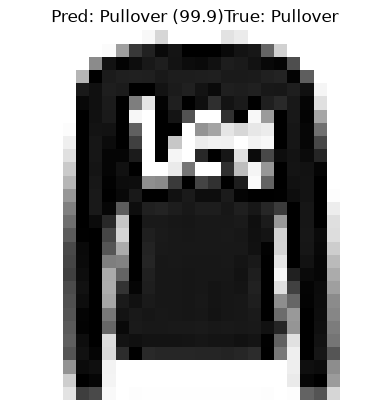

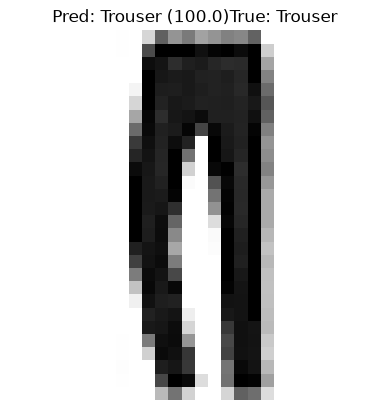

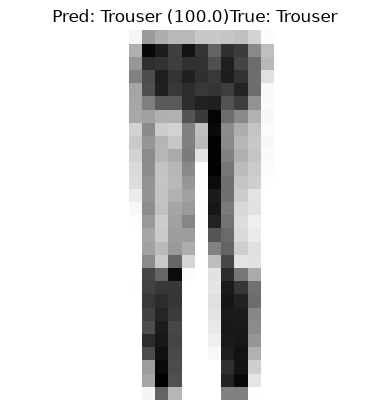

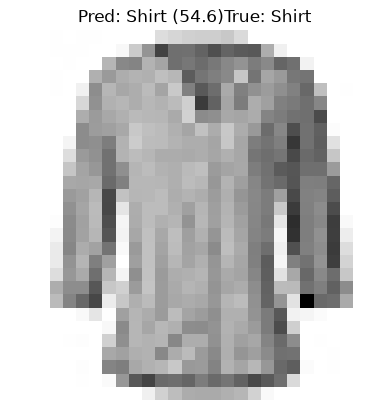

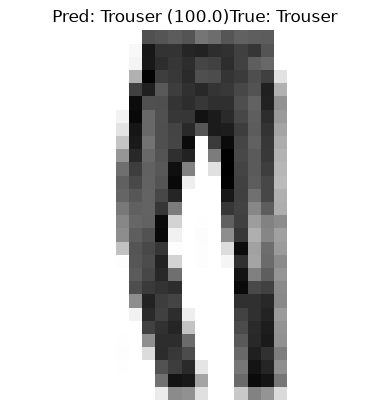

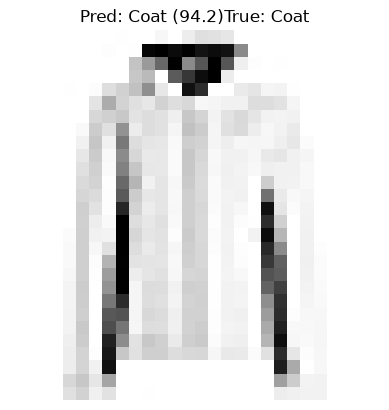

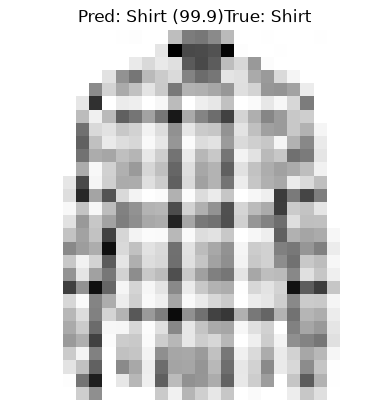

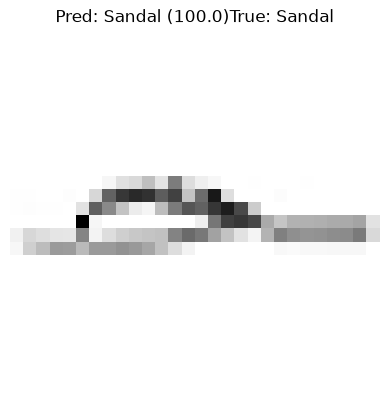

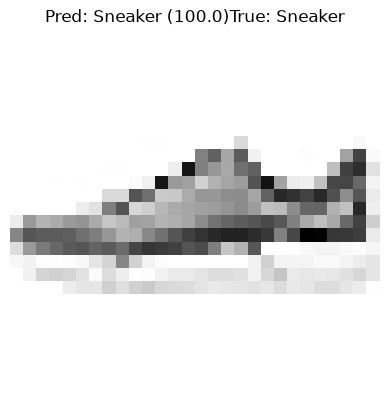

In [13]:
for i in range(1, 10):
    img, true_label = test_loader.dataset[i]
    predict_image(resnet_model, img, true_label, device=device)

сохраним наши модели

In [14]:
models_to_save = ['alexnet', 'vgg11']

for name in models_to_save:
    model = ModelFactory.get_model(name, num_classes=10, in_channels=1).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    trainer = Trainer(model=model, criterion=criterion, optimizer=optimizer, device=device)
    trainer.fit(train_loader, test_loader, epochs=5)
    
    save_path = save_dir / f'{name}_fashion.pth'
    torch.save(model.state_dict(), save_path)
print('Веса сохранены в model_checkpoints')


Эпоха [1/ 5]
Train loss: 0.6772, train acc: 0.7455
test loss: 0.4405, test acc 0.8416
Эпоха [2/ 5]
Train loss: 0.3830, train acc: 0.8640
test loss: 0.3663, test acc 0.8614
Эпоха [3/ 5]
Train loss: 0.3340, train acc: 0.8799
test loss: 0.3153, test acc 0.8894
Эпоха [4/ 5]
Train loss: 0.2994, train acc: 0.8924
test loss: 0.3199, test acc 0.8881
Эпоха [5/ 5]
Train loss: 0.2855, train acc: 0.8982
test loss: 0.3007, test acc 0.8942
Эпоха [1/ 5]
Train loss: 0.6932, train acc: 0.7328
test loss: 0.4115, test acc 0.8485
Эпоха [2/ 5]
Train loss: 0.3883, train acc: 0.8685
test loss: 0.3743, test acc 0.8755
Эпоха [3/ 5]
Train loss: 0.3263, train acc: 0.8885
test loss: 0.3311, test acc 0.8950
Эпоха [4/ 5]
Train loss: 0.2975, train acc: 0.8974
test loss: 0.3460, test acc 0.8813
Эпоха [5/ 5]
Train loss: 0.2740, train acc: 0.9066
test loss: 0.3014, test acc 0.9008
Веса сохранены в model_checkpoints


In [15]:
torch.save(resnet_model.state_dict(), "models_checkpoints/resnet18_fashion.pth")